In [2]:
import pandas as pd
import numpy as np

# Load the Amazon reviews dataset
df = pd.read_csv("data/amazonreviews.tsv", sep="\t")

# Display first 5 rows
print("First 5 rows:")
display(df.head())

# Dataset shape
print("\nDataset Shape:", df.shape)

# Dataset information
print("\nDataset Information:")
df.info()

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Check sentiment distribution
print("\nSentiment Distribution:")
print(df["label"].value_counts())

First 5 rows:


,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."



Dataset Shape: (10000, 2)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   10000 non-null  str  
 1   review  10000 non-null  str  
dtypes: str(2)
memory usage: 156.4 KB

Missing Values:
label     0
review    0
dtype: int64

Duplicate Rows: 0

Sentiment Distribution:
label
neg    5097
pos    4903
Name: count, dtype: int64


In [3]:
# Check missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# Remove rows with missing review or label
df = df.dropna(subset=["review", "label"])

# Remove duplicate rows
df = df.drop_duplicates()

# Reset index
df = df.reset_index(drop=True)

print("\nDataset after cleaning:")
print("Shape:", df.shape)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nDuplicate rows after cleaning:", df.duplicated().sum())

print("\nSentiment distribution:")
print(df["label"].value_counts())

Missing values before cleaning:
label     0
review    0
dtype: int64

Dataset after cleaning:
Shape: (10000, 2)

Missing values after cleaning:
label     0
review    0
dtype: int64

Duplicate rows after cleaning: 0

Sentiment distribution:
label
neg    5097
pos    4903
Name: count, dtype: int64


In [5]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Convert stopwords to a set for faster processing
stop_words = set(ENGLISH_STOP_WORDS)

# Function to clean review text
def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Split into words
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Join words back together
    return ' '.join(words)

# Apply preprocessing
df["cleaned_review"] = df["review"].apply(clean_text)

# Display original and cleaned reviews
display(df[["review", "cleaned_review"]].head(10))

,review,cleaned_review
0,Stuning even for the non-gamer: This sound tra...,stuning non gamer sound track beautiful paints...
1,The best soundtrack ever to anything.: I'm rea...,best soundtrack m reading lot reviews saying b...
2,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hands i...
3,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing ve played game...
5,an absolute masterpiece: I am quite sure any o...,absolute masterpiece quite sure actually takin...
6,"Buyer beware: This is a self-published book, a...",buyer beware self published book want know rea...
7,Glorious story: I loved Whisper of the wicked ...,glorious story loved whisper wicked saints sto...
8,A FIVE STAR BOOK: I just finished reading Whis...,star book just finished reading whisper wicked...
9,Whispers of the Wicked Saints: This was a easy...,whispers wicked saints easy read book want rea...


In [6]:
print("Original review:")
print(df["review"].iloc[0])

print("\nCleaned review:")
print(df["cleaned_review"].iloc[0])

print("\nNumber of reviews:", len(df))

Original review:
Stuning even for the non-gamer: This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^

Cleaned review:
stuning non gamer sound track beautiful paints senery mind recomend people hate vid game music played game chrono cross games played best music backs away crude keyboarding takes fresher step grate guitars soulful orchestras impress cares listen

Number of reviews: 10000


Sentiment Counts:
label
neg    5097
pos    4903
Name: count, dtype: int64


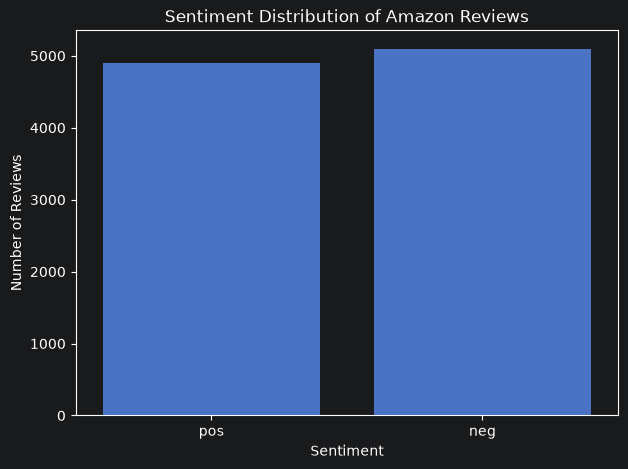

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count positive and negative reviews
sentiment_counts = df["label"].value_counts()

print("Sentiment Counts:")
print(sentiment_counts)

# Plot sentiment distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="label")

plt.title("Sentiment Distribution of Amazon Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

In [9]:
sentiment_percentage = df["label"].value_counts(normalize=True) * 100

print("Sentiment Percentage:")
print(sentiment_percentage.round(2))

Sentiment Percentage:
label
neg    50.97
pos    49.03
Name: proportion, dtype: float64


In [10]:
from collections import Counter

# Positive reviews
positive_text = " ".join(
    df.loc[df["label"] == "pos", "cleaned_review"]
)

# Negative reviews
negative_text = " ".join(
    df.loc[df["label"] == "neg", "cleaned_review"]
)

# Count words
positive_words = Counter(positive_text.split())
negative_words = Counter(negative_text.split())

print("Top 20 Positive Words:")
print(positive_words.most_common(20))

print("\nTop 20 Negative Words:")
print(negative_words.most_common(20))

Top 20 Positive Words:
[('book', 3390), ('s', 3179), ('great', 2135), ('t', 1871), ('good', 1667), ('read', 1605), ('like', 1290), ('movie', 1121), ('just', 1036), ('time', 924), ('love', 911), ('really', 832), ('best', 813), ('story', 730), ('cd', 618), ('music', 577), ('books', 543), ('little', 529), ('think', 512), ('don', 510)]

Top 20 Negative Words:
[('t', 3599), ('book', 3277), ('s', 2919), ('like', 1569), ('just', 1526), ('movie', 1519), ('read', 1222), ('good', 1160), ('don', 1135), ('time', 1072), ('buy', 835), ('really', 783), ('money', 767), ('bad', 764), ('did', 684), ('better', 677), ('great', 644), ('story', 641), ('product', 632), ('work', 624)]


In [11]:
# Improved text cleaning function
def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Remove apostrophes
    text = text.replace("'", "")

    # Keep only letters and spaces
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Split into words
    words = text.split()

    # Remove stopwords and single-character words
    words = [
        word for word in words
        if word not in stop_words and len(word) > 1
    ]

    return ' '.join(words)

# Apply improved preprocessing
df["cleaned_review"] = df["review"].apply(clean_text)

# Recreate positive and negative text
positive_text = " ".join(
    df.loc[df["label"] == "pos", "cleaned_review"]
)

negative_text = " ".join(
    df.loc[df["label"] == "neg", "cleaned_review"]
)

# Recalculate word frequencies
positive_words = Counter(positive_text.split())
negative_words = Counter(negative_text.split())

print("Top 20 Positive Words:")
print(positive_words.most_common(20))

print("\nTop 20 Negative Words:")
print(negative_words.most_common(20))

Top 20 Positive Words:
[('book', 3377), ('great', 2135), ('good', 1667), ('read', 1605), ('like', 1290), ('movie', 1116), ('just', 1036), ('time', 920), ('love', 911), ('really', 832), ('best', 813), ('story', 728), ('cd', 591), ('music', 576), ('books', 556), ('dont', 536), ('little', 529), ('think', 512), ('album', 500), ('life', 497)]

Top 20 Negative Words:
[('book', 3259), ('like', 1569), ('just', 1526), ('movie', 1514), ('dont', 1281), ('read', 1222), ('good', 1160), ('time', 1072), ('buy', 834), ('really', 783), ('money', 765), ('bad', 764), ('did', 682), ('better', 677), ('great', 643), ('story', 640), ('product', 631), ('work', 624), ('didnt', 582), ('im', 567)]


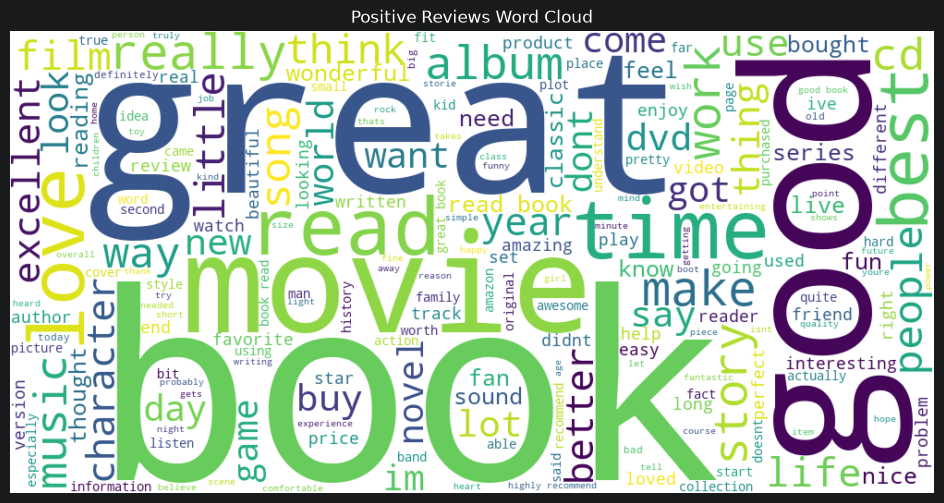

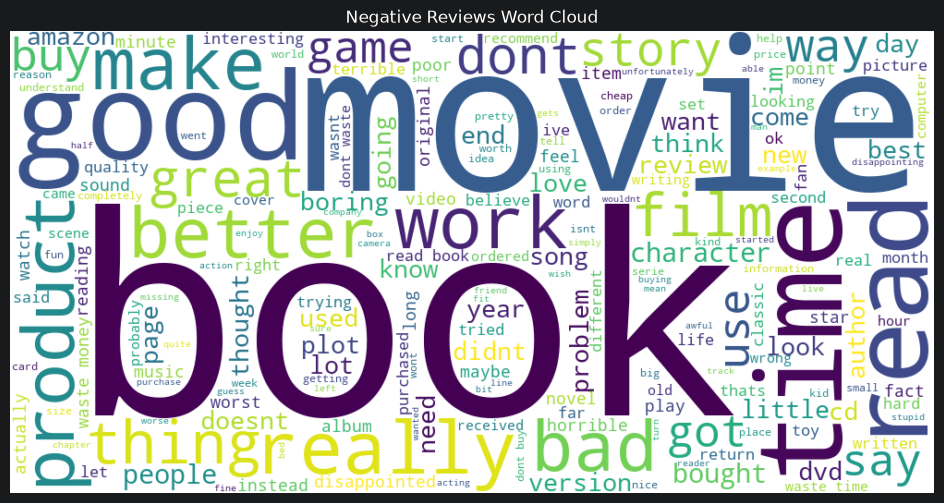

In [12]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Positive word cloud
positive_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(12, 6))
plt.imshow(positive_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Reviews Word Cloud")
plt.show()


# Negative word cloud
negative_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(negative_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Reviews Word Cloud")
plt.show()

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

# Transform cleaned reviews into TF-IDF features
X = tfidf.fit_transform(df["cleaned_review"])

# Target variable
y = df["label"]

print("TF-IDF feature extraction completed successfully.")
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

TF-IDF feature extraction completed successfully.
Feature matrix shape: (10000, 5000)
Target shape: (10000,)


In [14]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining sentiment distribution:")
print(y_train.value_counts())

print("\nTesting sentiment distribution:")
print(y_test.value_counts())

Training set shape: (8000, 5000)
Testing set shape: (2000, 5000)

Training sentiment distribution:
label
neg    4078
pos    3922
Name: count, dtype: int64

Testing sentiment distribution:
label
neg    1019
pos     981
Name: count, dtype: int64


In [15]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Make predictions
y_pred_lr = logistic_model.predict(X_test)

# Calculate evaluation metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, pos_label="pos")
recall_lr = recall_score(y_test, y_pred_lr, pos_label="pos")
f1_lr = f1_score(y_test, y_pred_lr, pos_label="pos")

print("Logistic Regression Performance")
print("--------------------------------")
print("Accuracy :", accuracy_lr)
print("Precision:", precision_lr)
print("Recall   :", recall_lr)
print("F1-Score :", f1_lr)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Performance
--------------------------------
Accuracy : 0.8565
Precision: 0.8599585062240664
Recall   : 0.8450560652395515
F1-Score : 0.8524421593830335

Classification Report:
              precision    recall  f1-score   support

         neg       0.85      0.87      0.86      1019
         pos       0.86      0.85      0.85       981

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



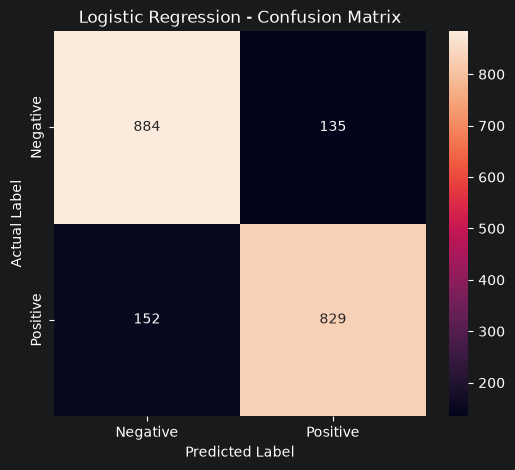

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=["neg", "pos"])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [18]:
print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy : {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall   : {recall_lr:.4f}")
print(f"F1-Score : {f1_lr:.4f}")

Logistic Regression Performance
--------------------------------
Accuracy : 0.8565
Precision: 0.8600
Recall   : 0.8451
F1-Score : 0.8524


In [19]:
from sklearn.svm import LinearSVC

# Create Linear SVM model
svm_model = LinearSVC(
    random_state=42,
    max_iter=2000
)

# Train the model
svm_model.fit(X_train, y_train)

print("Linear SVM model trained successfully.")

Linear SVM model trained successfully.


In [20]:
# Make predictions
y_pred_svm = svm_model.predict(X_test)

# Calculate evaluation metrics
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, pos_label="pos")
recall_svm = recall_score(y_test, y_pred_svm, pos_label="pos")
f1_svm = f1_score(y_test, y_pred_svm, pos_label="pos")

print("Linear SVM Performance")
print("----------------------")
print(f"Accuracy : {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall   : {recall_svm:.4f}")
print(f"F1-Score : {f1_svm:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

Linear SVM Performance
----------------------
Accuracy : 0.8455
Precision: 0.8367
Recall   : 0.8512
F1-Score : 0.8439

Classification Report:
              precision    recall  f1-score   support

         neg       0.85      0.84      0.85      1019
         pos       0.84      0.85      0.84       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



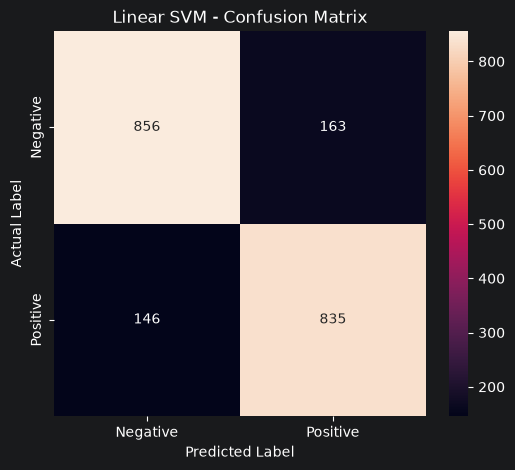

In [21]:
cm_svm = confusion_matrix(
    y_test,
    y_pred_svm,
    labels=["neg", "pos"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Linear SVM - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [22]:
print("Linear SVM Performance")
print("----------------------")
print(f"Accuracy : {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall   : {recall_svm:.4f}")
print(f"F1-Score : {f1_svm:.4f}")

Linear SVM Performance
----------------------
Accuracy : 0.8455
Precision: 0.8367
Recall   : 0.8512
F1-Score : 0.8439


In [23]:
from sklearn.model_selection import cross_val_score

# 5-fold cross-validation for Logistic Regression
lr_cv_scores = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# 5-fold cross-validation for Linear SVM
svm_cv_scores = cross_val_score(
    svm_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("5-Fold Cross-Validation Results")
print("--------------------------------")

print("\nLogistic Regression:")
print("Fold scores:", lr_cv_scores)
print("Mean Accuracy:", lr_cv_scores.mean())
print("Standard Deviation:", lr_cv_scores.std())

print("\nLinear SVM:")
print("Fold scores:", svm_cv_scores)
print("Mean Accuracy:", svm_cv_scores.mean())
print("Standard Deviation:", svm_cv_scores.std())

5-Fold Cross-Validation Results
--------------------------------

Logistic Regression:
Fold scores: [0.850625 0.84625  0.86625  0.85375  0.850625]
Mean Accuracy: 0.8535
Standard Deviation: 0.006807624402095055

Linear SVM:
Fold scores: [0.82875  0.82875  0.868125 0.8325   0.836875]
Mean Accuracy: 0.8390000000000001
Standard Deviation: 0.014867119761406391


In [24]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid_lr = {
    "C": [0.01, 0.1, 1, 10, 100]
}

# Create base Logistic Regression model
lr_base = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Grid Search with 5-fold cross-validation
grid_lr = GridSearchCV(
    estimator=lr_base,
    param_grid=param_grid_lr,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Fit Grid Search
grid_lr.fit(X_train, y_train)

print("Best Parameters:", grid_lr.best_params_)
print("Best Cross-Validation Accuracy:", grid_lr.best_score_)

Best Parameters: {'C': 1}
Best Cross-Validation Accuracy: 0.8535


In [25]:
# Get the best Logistic Regression model
best_lr = grid_lr.best_estimator_

# Make predictions on the test set
y_pred_best_lr = best_lr.predict(X_test)

# Calculate evaluation metrics
accuracy_best_lr = accuracy_score(y_test, y_pred_best_lr)
precision_best_lr = precision_score(
    y_test, y_pred_best_lr, pos_label="pos"
)
recall_best_lr = recall_score(
    y_test, y_pred_best_lr, pos_label="pos"
)
f1_best_lr = f1_score(
    y_test, y_pred_best_lr, pos_label="pos"
)

print("Tuned Logistic Regression Performance")
print("--------------------------------------")
print(f"Accuracy : {accuracy_best_lr:.4f}")
print(f"Precision: {precision_best_lr:.4f}")
print(f"Recall   : {recall_best_lr:.4f}")
print(f"F1-Score : {f1_best_lr:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_lr))

Tuned Logistic Regression Performance
--------------------------------------
Accuracy : 0.8565
Precision: 0.8600
Recall   : 0.8451
F1-Score : 0.8524

Classification Report:
              precision    recall  f1-score   support

         neg       0.85      0.87      0.86      1019
         pos       0.86      0.85      0.85       981

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



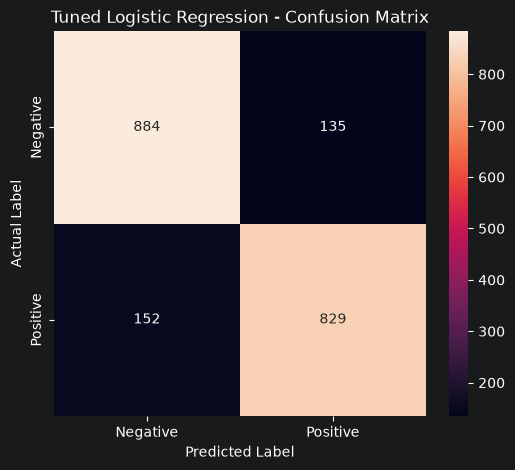

In [26]:
cm_best_lr = confusion_matrix(
    y_test,
    y_pred_best_lr,
    labels=["neg", "pos"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_best_lr,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Tuned Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [27]:
# Model comparison
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM",
        "Tuned Logistic Regression"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_svm,
        accuracy_best_lr
    ],
    "Precision": [
        precision_lr,
        precision_svm,
        precision_best_lr
    ],
    "Recall": [
        recall_lr,
        recall_svm,
        recall_best_lr
    ],
    "F1-Score": [
        f1_lr,
        f1_svm,
        f1_best_lr
    ]
})

# Round values
model_comparison = model_comparison.round(4)

print("Model Performance Comparison")
print("----------------------------")
display(model_comparison)

Model Performance Comparison
----------------------------


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8565,0.8600,0.8451,0.8524
1,Linear SVM,0.8455,0.8367,0.8512,0.8439
2,Tuned Logistic Regression,0.8565,0.8600,0.8451,0.8524


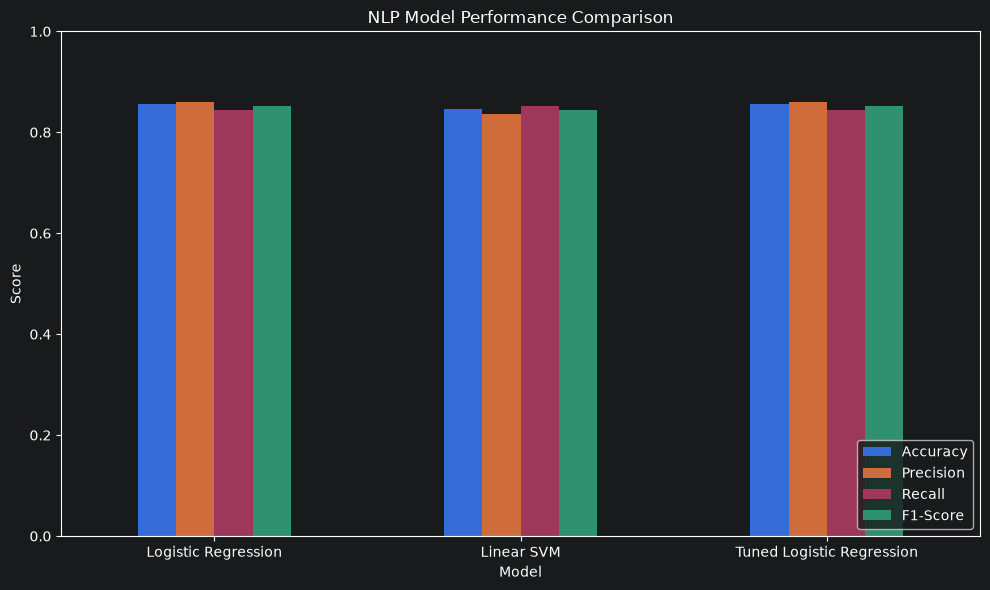

In [28]:
# Plot model comparison
model_comparison.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("NLP Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [29]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get probability scores for the positive class
y_prob_lr = best_lr.predict_proba(X_test)[:, 1]

# Convert actual labels to binary
y_test_binary = (y_test == "pos").astype(int)

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_test_binary, y_prob_lr)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(
    y_test_binary,
    y_prob_lr
)

print("Tuned Logistic Regression ROC-AUC Score:")
print(f"{roc_auc:.4f}")

Tuned Logistic Regression ROC-AUC Score:
0.9253


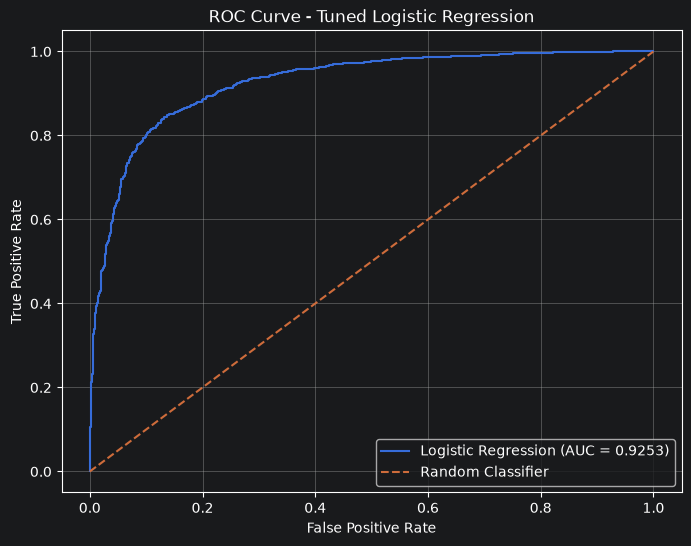

In [30]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Logistic Regression")
plt.legend()
plt.grid()
plt.show()

In [31]:
# Function to predict sentiment of a new review

def predict_sentiment(review):
    # Clean the review using our preprocessing function
    cleaned = clean_text(review)

    # Convert the review into TF-IDF features
    review_tfidf = tfidf.transform([cleaned])

    # Predict sentiment
    prediction = best_lr.predict(review_tfidf)[0]

    # Get prediction probability
    probabilities = best_lr.predict_proba(review_tfidf)[0]

    # Get probability of predicted class
    class_index = list(best_lr.classes_).index(prediction)
    confidence = probabilities[class_index]

    return prediction, confidence


# Test reviews
test_reviews = [
    "This product is excellent and I absolutely love it.",
    "The product is terrible and completely disappointed me.",
    "Amazing quality, very happy with my purchase.",
    "Worst product I have ever bought. Very poor quality."
]

print("New Review Predictions")
print("======================")

for review in test_reviews:
    sentiment, confidence = predict_sentiment(review)

    print("\nReview:", review)
    print("Predicted Sentiment:", sentiment.upper())
    print(f"Confidence: {confidence:.2%}")

New Review Predictions

Review: This product is excellent and I absolutely love it.
Predicted Sentiment: POS
Confidence: 94.32%

Review: The product is terrible and completely disappointed me.
Predicted Sentiment: NEG
Confidence: 98.85%

Review: Amazing quality, very happy with my purchase.
Predicted Sentiment: POS
Confidence: 86.72%

Review: Worst product I have ever bought. Very poor quality.
Predicted Sentiment: NEG
Confidence: 99.11%


In [32]:
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save the trained model
joblib.dump(
    best_lr,
    "models/sentiment_logistic_regression.pkl"
)

# Save the TF-IDF vectorizer
joblib.dump(
    tfidf,
    "models/tfidf_vectorizer.pkl"
)

print("Final model and TF-IDF vectorizer saved successfully.")

print("\nSaved files:")
print("1. models/sentiment_logistic_regression.pkl")
print("2. models/tfidf_vectorizer.pkl")

Final model and TF-IDF vectorizer saved successfully.

Saved files:
1. models/sentiment_logistic_regression.pkl
2. models/tfidf_vectorizer.pkl


In [33]:
print("Files inside models folder:")

for file in os.listdir("models"):
    print("-", file)

Files inside models folder:
- tfidf_vectorizer.pkl
- sentiment_logistic_regression.pkl


Final conclusion

Tuned Logistic Regression with TF-IDF is the selected final model. It achieved 85.65% test accuracy, 85.24% F1-score, and an excellent 0.9253 ROC-AUC, while also showing stable 5-fold cross-validation performance.

Your notebook is now essentially complete from the technical/modeling side. The remaining part is the written report/documentation explaining the methodology, results, interpretation, limitations, and conclusion.